In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
import sklearn as sk

# Import Data

Import the data and set up the variables:
- `TARGET`
- `categorical_features`
- `numeric_features`

In [2]:
df = pd.read_csv("data/bank-additional-full.csv", sep=";")

# constant for referencing target
TARGET = "y"

# identify categorical and numeric features
categorical_features = df.select_dtypes(include=["object"]).columns
numeric_features = df.columns.difference(categorical_features)

# target is not a feature
categorical_features = categorical_features.drop(TARGET)

print("Categorical features:", categorical_features.tolist())
print("Numeric features:", numeric_features.tolist())

# make sure we didn't drop any variable
if len(df.columns) - 1 != len(categorical_features) + len(numeric_features):
    raise RuntimeError("Feature count doesn't add up")

df

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric features: ['age', 'campaign', 'cons.conf.idx', 'cons.price.idx', 'duration', 'emp.var.rate', 'euribor3m', 'nr.employed', 'pdays', 'previous']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


# EDA

In [3]:
# change target to be numeric
df[TARGET] = df[TARGET].map({"yes": 1, "no": 0})

# remove `duration` from features (see readme for why)
if "duration" in numeric_features:
    numeric_features = numeric_features.drop("duration")

The dataset is not balanced, only about 11% of it has `TARGET == True`.

In [4]:
df[TARGET].mean()

np.float64(0.11265417111780131)

### Data Consistency

Here we check that all the object variables don't have any funny values. They look alright:

In [5]:
for col in categorical_features:
    print(f"{col:<12}: {df[col].unique()}")

job         : ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital     : ['married' 'single' 'divorced' 'unknown']
education   : ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default     : ['no' 'unknown' 'yes']
housing     : ['no' 'yes' 'unknown']
loan        : ['no' 'yes' 'unknown']
contact     : ['telephone' 'cellular']
month       : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week : ['mon' 'tue' 'wed' 'thu' 'fri']
poutcome    : ['nonexistent' 'failure' 'success']


Now, we check the numeric features and see if we can find any strange behaviour here.

In [6]:
numeric_stats = pd.DataFrame(
    {
        "mean": df[numeric_features].mean().round(1),
        "min": df[numeric_features].min().round(1),
        "max": df[numeric_features].max().round(1),
        "var": df[numeric_features].var().round(1),
        "NaN?": df[numeric_features].isna().sum(),
    }
)
# Add a new column with descriptions for each statistic
numeric_stats["Description"] = [
    "Age of customer",
    "Total contacts in campaign (incl. last)",
    "Consumer confidence index (monthly)",
    "Consumer price index (monthly)",
    "Employment variation rate (quarterly)",
    "Euribor 3-month rate (daily)",
    "Number of employees (quarterly)",
    "Days since last campaign contact (999 = never)",
    "Number of contacts before this campaign",
]
numeric_stats

,mean,min,max,var,NaN?,Description
age,40.0,17.0,98.0,108.6,0,Age of customer
campaign,2.6,1.0,56.0,7.7,0,Total contacts in campaign (incl. last)
cons.conf.idx,-40.5,-50.8,-26.9,21.4,0,Consumer confidence index (monthly)
cons.price.idx,93.6,92.2,94.8,0.3,0,Consumer price index (monthly)
emp.var.rate,0.1,-3.4,1.4,2.5,0,Employment variation rate (quarterly)
euribor3m,3.6,0.6,5.0,3.0,0,Euribor 3-month rate (daily)
nr.employed,5167.0,4963.6,5228.1,5220.3,0,Number of employees (quarterly)
pdays,962.5,0.0,999.0,34935.7,0,Days since last campaign contact (999 = never)
previous,0.2,0.0,7.0,0.2,0,Number of contacts before this campaign


There are no NaN values, and most of the variables look fine.

Some important points:
- The variance of `age` is quite high relative to its range, but I won't do anything about it.
- `pdays` also has a very high variance. This is because "no contact" is coded as 999. We'll have to deal with that soon.

Minor nitpicks:
- The range of `age` is 17-98 🧐. Is it even allowed to telemarket to underage children? And what about calling 98-year-olds? All a bit odd.
- The maximum `campaign` value of 56 means one customer was called 56 times, which is impressive and probably rather annoying.
- I'm not quite sure what `nr.employed` refers to, but that's fine; we don't need the exact unit for training.

# Baseline

We establish a baseline that we use for the rest of the notebook.

In [7]:
# Random seed for whole notebook
SEED = 1

# split data
df_train_full, df_test = sk.model_selection.train_test_split(
    df, test_size=0.2, random_state=SEED
)
df_train, df_val = sk.model_selection.train_test_split(
    df_train_full, test_size=0.2 / 0.8, random_state=SEED
)

y_train_full = df_train_full.pop(TARGET)
y_train = df_train.pop(TARGET)
y_val = df_val.pop(TARGET)
y_test = df_test.pop(TARGET)

print(len(df_train), len(df_test), len(df_val))

24712 8238 8238


Baseline ap: 0.4436561562196932


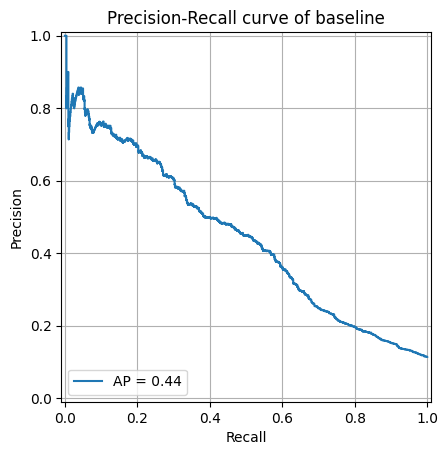

In [8]:
ALL_FEATURES = categorical_features.union(numeric_features)


def get_data_preparation_pipeline():
    return sk.pipeline.make_pipeline(
        sk.feature_extraction.DictVectorizer(sparse=False),  # one-hot-encoding
        sk.preprocessing.StandardScaler(),  # scaling speeds up learning a lot
    )


def basic_linear_regression(
    df_train, y_train, df_val, features=ALL_FEATURES, seed=SEED
):

    logistic_regression_pipeline = sk.pipeline.make_pipeline(
        get_data_preparation_pipeline(),
        sk.linear_model.LogisticRegression(random_state=seed),
    )

    # train
    dict_train = df_train[features].to_dict(orient="records")
    logistic_regression_pipeline.fit(dict_train, y_train)

    # predicts
    dict_val = df_val[features].to_dict(orient="records")
    y_val_prob = logistic_regression_pipeline.predict_proba(dict_val)[:, 1]

    return y_val_prob


# baseline auc
y_val_prob = basic_linear_regression(df_train, y_train, df_val)
BASE_AP = sk.metrics.average_precision_score(y_val, y_val_prob)
print(f"Baseline ap: {BASE_AP}")

# check precision-recall curve
precision, recall, thresholds = sk.metrics.precision_recall_curve(y_val, y_val_prob)
sk.metrics.PrecisionRecallDisplay(
    precision=precision, recall=recall, average_precision=BASE_AP
).plot()
plt.title("Precision-Recall curve of baseline")
plt.grid(True)

Since the dataset has 10% positives, the AP of a random classifier is 0.1, the closer to 1, the better.

# Feature Preparation

We have to deal with `pdays` now. I want to address the high variance in `pdays`, and also the fact that its flag value of 999 for "never contacted" might interfere with its normal data range.

First, let’s look at how large `pdays` typically is, to make sure that 999 does not fall within its usual data range.

In [9]:
df["pdays"].value_counts().sort_index()

pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64

We can conclude that 999 is not accidentally the actual number of days since the last contact of the previous campaign. It might be better to map 999 → -1 to push this flag value outside the normal data range and reduce the variance.

Also, there is something a bit fishy about pdays.

We have three features relating to a possible previous campaign:
- `poutcome`
- `previous`
- `pdays`

One might expect that, if a client has not been part of any previous campaign, these features would take the following values: `poutcome == 'nonexistent'`, `previous == 0`, and `pdays == 999`.

For `poutcome` and `previous`, this holds:

In [10]:
crosstab = pd.crosstab(df["poutcome"] == "nonexistent", df["previous"] == 0)
crosstab

previous,False,True
poutcome,,
False,5625,0
True,0,35563


However, for `pdays` we have an inconsistency: there are 4,110 rows where `pdays == 999` but `poutcome == 'failure'`.

In [11]:
crosstab = pd.crosstab(df["poutcome"], df["pdays"] == 999)
crosstab

pdays,False,True
poutcome,,
failure,142,4110
nonexistent,0,35563
success,1373,0


So let's see whether we can improve performance by feature engineering `pdays`.

We want to test two changes to `pdays` handling:
- Replace the missing-flag 999 for "never contacted in previous campaign" by a different -1. This moves the special value out of the normal numeric range.
- For rows where `pdays` is the missing-flag but `poutcome == 'failure'`, I suspect those are inconsistent (they claim the outcome of a previous contact but also say "never contacted"). For those rows we assign a default_value (e.g. 0, mean(pdays), 10, 100) to see whether a a default value improves model AUC.

In [12]:
# compute mean of pdays (without 999)
mean_pdays = df[df["pdays"] != 999]["pdays"].mean()
mean_pdays = int(round(mean_pdays))

print(f"Mean of pdays without is roughly: {mean_pdays}")


def feature_preparation_pdays(missing_flag, default_value):
    df_train_copy = df_train.copy()
    df_val_copy = df_val.copy()

    # Step 1: mark original 'never contacted' values (999) with the chosen missing_flag
    df_train_copy["pdays"] = df_train_copy["pdays"].replace(999, missing_flag)
    df_val_copy["pdays"] = df_val_copy["pdays"].replace(999, missing_flag)

    # Step 2: override inconsistent rows where poutcome == 'failure' but pdays is missing_flag
    mask_train = (df_train_copy["pdays"] == missing_flag) & (
        df_train_copy["poutcome"] == "failure"
    )
    df_train_copy.loc[mask_train, "pdays"] = default_value
    mask_val = (df_val_copy["pdays"] == missing_flag) & (
        df_val_copy["poutcome"] == "failure"
    )
    df_val_copy.loc[mask_val, "pdays"] = default_value

    # train and return predicted probabilities
    y_val_prob = basic_linear_regression(
        df_train_copy,
        y_train,
        df_val_copy,
    )
    return sk.metrics.average_precision_score(y_val, y_val_prob)


for missing_flag in [-1, 999]:
    for default_value in [-1, 0, 1, mean_pdays, 999]:
        ap = feature_preparation_pdays(missing_flag, default_value)
        print(
            f"missing: {missing_flag}, default: {default_value} -> {ap:.3f}, "
            f"(relative to base: {ap/BASE_AP*100:.1f}%)"
        )

Mean of pdays without is roughly: 6
missing: -1, default: -1 -> 0.443, (relative to base: 99.9%)
missing: -1, default: 0 -> 0.443, (relative to base: 99.9%)
missing: -1, default: 1 -> 0.443, (relative to base: 99.8%)
missing: -1, default: 6 -> 0.442, (relative to base: 99.6%)
missing: -1, default: 999 -> 0.444, (relative to base: 100.1%)
missing: 999, default: -1 -> 0.442, (relative to base: 99.7%)
missing: 999, default: 0 -> 0.442, (relative to base: 99.7%)
missing: 999, default: 1 -> 0.442, (relative to base: 99.7%)
missing: 999, default: 6 -> 0.442, (relative to base: 99.7%)
missing: 999, default: 999 -> 0.444, (relative to base: 100.0%)


These changes don't really affect the score, so for simplicity I won't change the data.

## Feature selection

We will try to pare down the number of features and see whether that improves our score.

We use a greedy feature-elimination procedure: we train models for every candidate feature removal, measure validation AP (averaged across folds). We identify the "worst" feature, whose removal results in the biggest AP and repeat.

__Note__: This might take a while (it has to perform 5 * 19 = 95 training iterations). You can skip it if you like.

In [13]:
n_folds = 5


def features_score(features):
    kfold = sk.model_selection.KFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    scores = []
    for train_idx, val_idx in kfold.split(df_train_full):
        df_train_fold, df_val_fold = (
            df_train_full.iloc[train_idx],
            df_train_full.iloc[val_idx],
        )
        y_train_fold, y_val_fold = (
            y_train_full.iloc[train_idx],
            y_train_full.iloc[val_idx],
        )
        y_val_prob = basic_linear_regression(
            df_train_fold, y_train_fold, df_val_fold, features=features, seed=SEED
        )
        scores.append(sk.metrics.average_precision_score(y_val_fold, y_val_prob))
    return np.mean(scores) / BASE_AP


current_features = ALL_FEATURES.copy()

feature_importance = {}

while current_features.size > 1:
    candidate_scores = {
        feature: features_score(current_features.drop(feature))
        for feature in current_features
    }
    # The feature whose removal yields the **highest** AP is considered the worst feature.
    worst_feature = max(candidate_scores, key=candidate_scores.get)
    feature_importance[worst_feature] = candidate_scores[worst_feature]
    print(
        f"Removing (worst) feature out of {len(current_features)}: {worst_feature}",
        f"-> {candidate_scores[worst_feature]*100:.2f}% of base AP ",
    )
    current_features = current_features.drop(worst_feature)

print(f"Last remaining feature is {current_features[0]}")

Removing (worst) feature out of 19: job -> 101.38% of base AP 
Removing (worst) feature out of 18: education -> 101.59% of base AP 
Removing (worst) feature out of 17: previous -> 101.76% of base AP 
Removing (worst) feature out of 16: loan -> 101.79% of base AP 
Removing (worst) feature out of 15: nr.employed -> 101.83% of base AP 
Removing (worst) feature out of 14: housing -> 101.80% of base AP 
Removing (worst) feature out of 13: marital -> 101.77% of base AP 
Removing (worst) feature out of 12: cons.conf.idx -> 101.88% of base AP 
Removing (worst) feature out of 11: age -> 101.77% of base AP 
Removing (worst) feature out of 10: pdays -> 101.61% of base AP 
Removing (worst) feature out of 9: default -> 101.44% of base AP 
Removing (worst) feature out of 8: campaign -> 100.82% of base AP 
Removing (worst) feature out of 7: euribor3m -> 100.11% of base AP 
Removing (worst) feature out of 6: contact -> 98.44% of base AP 
Removing (worst) feature out of 5: day_of_week -> 95.39% of base

Removing any of these scores doesn't really affect the score (job is the worst in the first iteration, so removing any of the others result in a lower AP score).

However for the sake of this project (length & simplicity) I will use a restricted set of features that still result in a relatively good score compared to the base (the exact cut-off is a bit arbitrary).

In [14]:
RESTRICTED_FEATURES = [
    "age",
    "pdays",
    "default",
    "campaign",
    "euribor3m",
    "contact",
    "day_of_week",
    "month",
    "cons.price.idx",
    "poutcome",
    "emp.var.rate",
]

# Model Training

We prepare the data for tuning a linear model and a tree based model.

In [15]:
dict_train_full = df_train_full[RESTRICTED_FEATURES].to_dict(orient="records")
data_preparation_pipeline = get_data_preparation_pipeline()
X_train_full = data_preparation_pipeline.fit_transform(dict_train_full)

For fine tuning we can use `sklearn.model_selection`

## Tuning Linear Model

In [16]:
log_reg = sk.linear_model.LogisticRegression(random_state=SEED)

param_grid = {
    "C": [0.01, 0.1, 1, 5, 10],
    "tol": [0.01, 0.1, 0.0001],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs", "liblinear", "saga", "newton-cholesky"],
    "max_iter": [2_000],
}

log_reg_grid = sk.model_selection.GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring="average_precision",
    n_jobs=-1,
)

log_reg_grid.fit(X_train_full, y_train_full)

print("Best params:", log_reg_grid.best_params_)
print(
    f"Best score: {log_reg_grid.best_score_} ({log_reg_grid.best_score_/BASE_AP*100:.2f}%)"
)

Best params: {'C': 10, 'class_weight': None, 'max_iter': 2000, 'solver': 'saga', 'tol': 0.0001}
Best score: 0.45236096215601374 (101.96%)


## Tuning Tree-based model

We do the tree search in two runs. One with fewer trees and another with more.

In [ ]:
rf = sk.ensemble.RandomForestClassifier(
    random_state=SEED,
    n_jobs=1,  # if I use anything bigger than 1, my system starts to stutter.
)

param_grid_stage1 = {
    "n_estimators": [100],
    "max_depth": [3, 20, 50],
    "min_samples_leaf": [5, 20, 100],
    "max_features": ["sqrt", None],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced"],
}


rf_search = sk.model_selection.GridSearchCV(
    estimator=rf,
    param_grid=param_grid_stage1,
    cv=3,
    scoring="average_precision",
    n_jobs=1,
)

rf_search.fit(X_train_full, y_train_full)

print("Best params:", rf_search.best_params_)
print(f"Best score: {rf_search.best_score_} ({rf_search.best_score_/BASE_AP*100:.2f}%)")

Best params: {'bootstrap': False, 'class_weight': None, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 100}
Best score: 0.4702444401262424 (105.99%)


In [21]:
# second run with some of the best parameters from above

rf = sk.ensemble.RandomForestClassifier(
    random_state=SEED,
    n_jobs=1,
)

param_grid_stage2 = {
    "n_estimators": [100, 400, 800],
    "max_depth": [10, 20],
    "min_samples_leaf": [20, 30],
    "max_features": ["sqrt"],
    "bootstrap": [False],
    "class_weight": [None],
}


rf_search2 = sk.model_selection.GridSearchCV(
    estimator=rf,
    param_grid=param_grid_stage2,
    cv=5,
    scoring="average_precision",
    n_jobs=1,
)

rf_search2.fit(X_train_full, y_train_full)

print("Best params:", rf_search2.best_params_)
print(
    f"Best score: {rf_search2.best_score_} ({rf_search2.best_score_/BASE_AP*100:.2f}%)"
)

Best params: {'bootstrap': False, 'class_weight': None, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'n_estimators': 800}
Best score: 0.4735988607532991 (106.75%)


# Validation

The random forest produces the best results with these parameters:

In [ ]:
rf_best_params = {
    "bootstrap": False,
    "class_weight": None,
    "max_depth": 20,
    "max_features": "sqrt",
    "min_samples_leaf": 20,
    "n_estimators": 800,
}

Test ap: 0.4777394896323207 (102.6%)


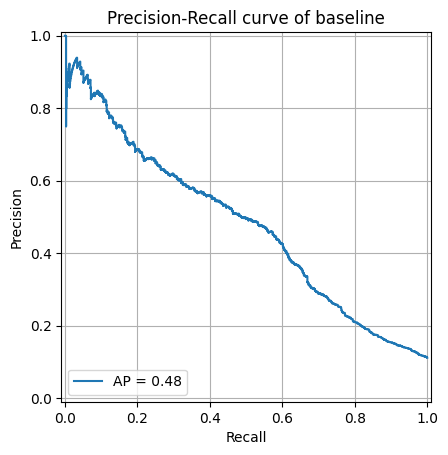

In [51]:
# all features
dict_train_full = df_train_full[ALL_FEATURES].to_dict(orient="records")
data_preparation_pipeline = get_data_preparation_pipeline()
X_train_full = data_preparation_pipeline.fit_transform(dict_train_full)

# train
rf = sk.ensemble.RandomForestClassifier(
    **rf_search.best_params_,
    random_state=SEED,
    n_jobs=-1,
)

rf.fit(X_train_full, y_train_full)


# evaluate
dict_test = df_test[ALL_FEATURES].to_dict(orient="records")
X_test = data_preparation_pipeline.transform(dict_test)
y_test_prob = rf.predict_proba(X_test)[:, 1]


# eval ap
test_ap = sk.metrics.average_precision_score(y_test, y_test_prob)
print(f"Test ap: {test_ap} ({test_ap/BASE_AP*100:.1f}%)")

# check precision-recall curve
precision, recall, thresholds = sk.metrics.precision_recall_curve(y_test, y_test_prob)
sk.metrics.PrecisionRecallDisplay(
    precision=precision, recall=recall, average_precision=test_ap
).plot()
plt.title("Precision-Recall curve of baseline")
plt.grid(True)

# Example entry for the API

In [52]:
df_test[ALL_FEATURES].iloc[10]

age                              29
campaign                          1
cons.conf.idx                 -40.0
cons.price.idx               93.876
contact                    cellular
day_of_week                     thu
default                          no
education         university.degree
emp.var.rate                   -1.8
euribor3m                     0.683
housing                          no
job                          admin.
loan                             no
marital                      single
month                           may
nr.employed                  5008.7
pdays                             3
poutcome                    success
previous                          3
Name: 39660, dtype: object